hyperparameter: degree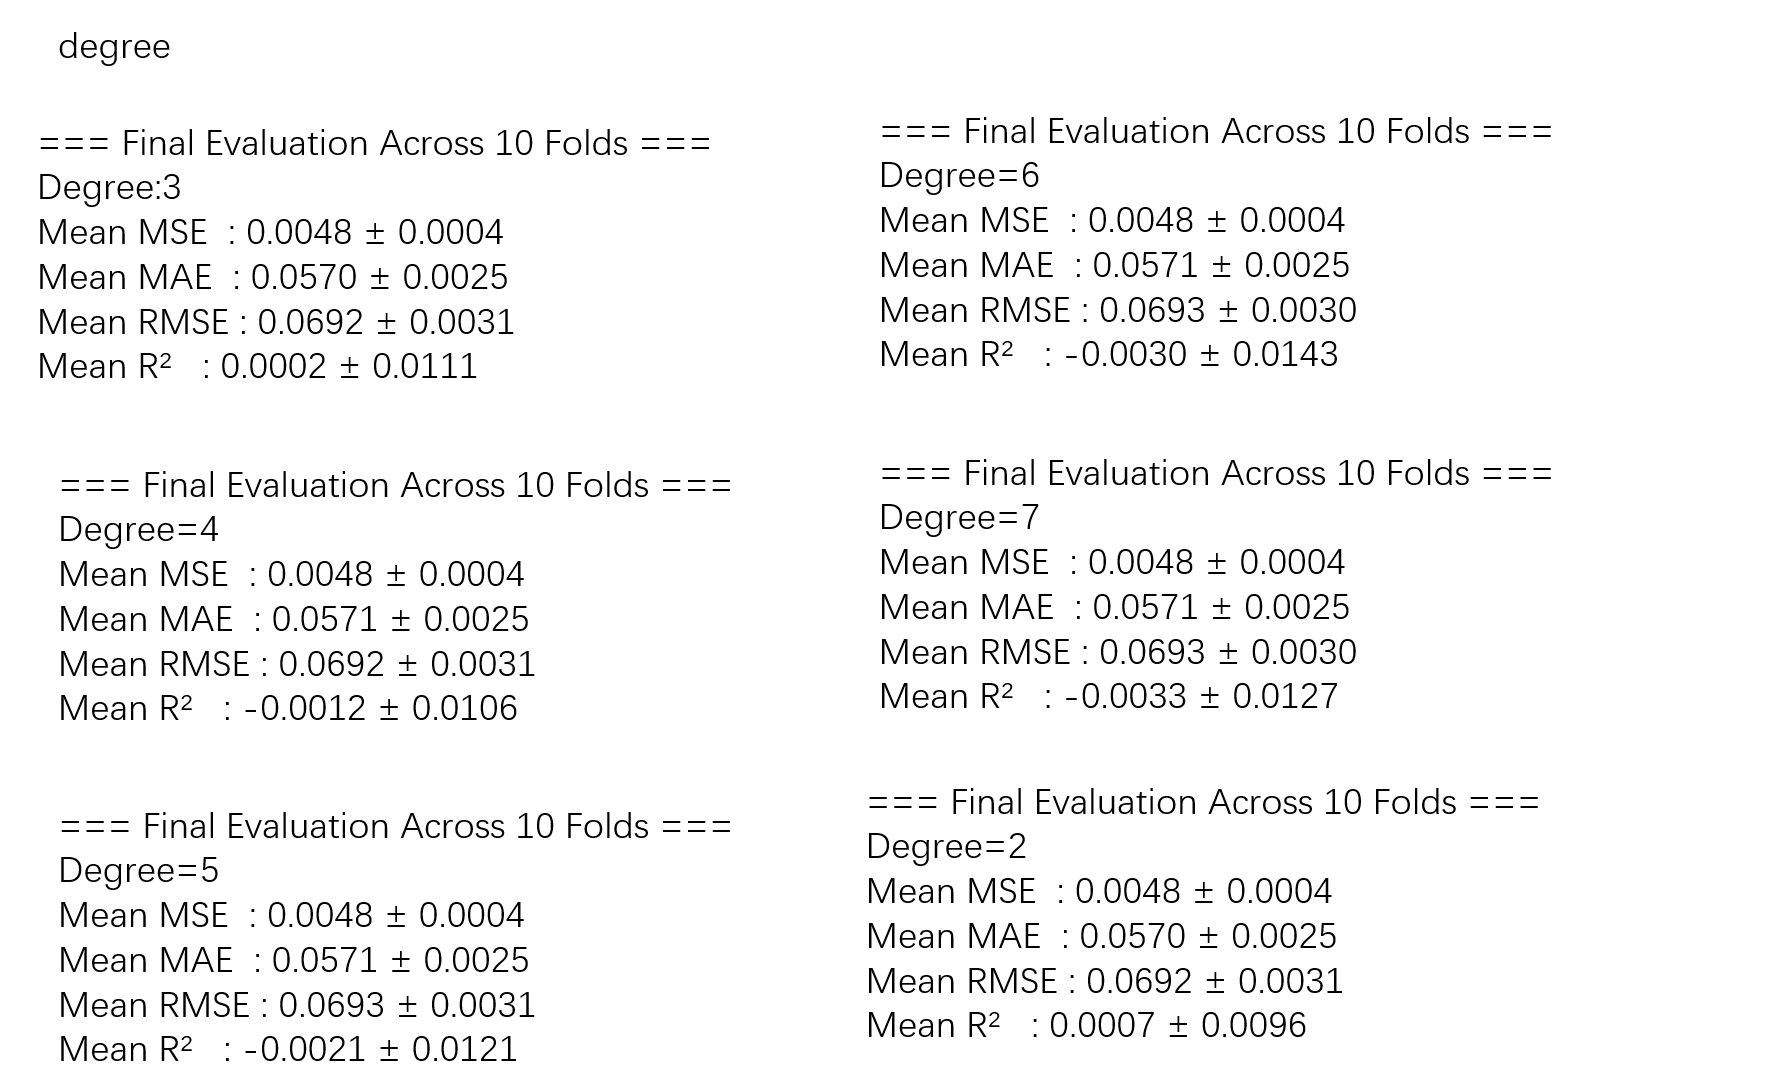


=== Fold 1 ===
MSE  : 0.0046
MAE  : 0.0565
RMSE : 0.0679
R²   : 0.0161


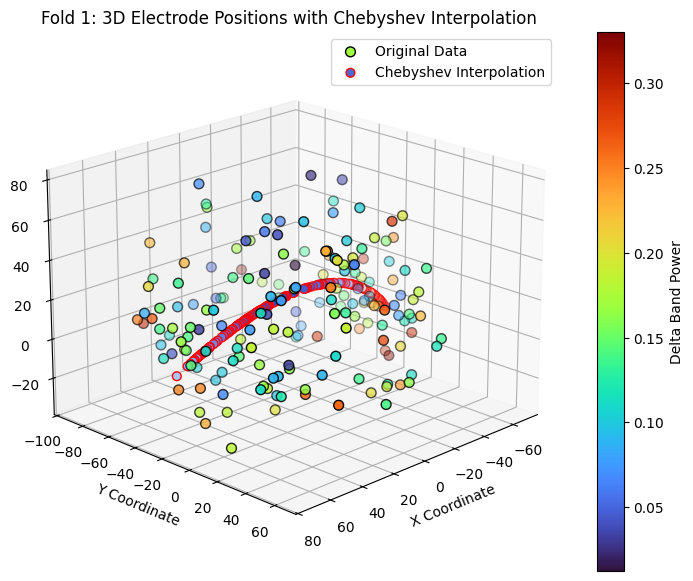


=== Fold 2 ===
MSE  : 0.0053
MAE  : 0.0593
RMSE : 0.0729
R²   : 0.0013


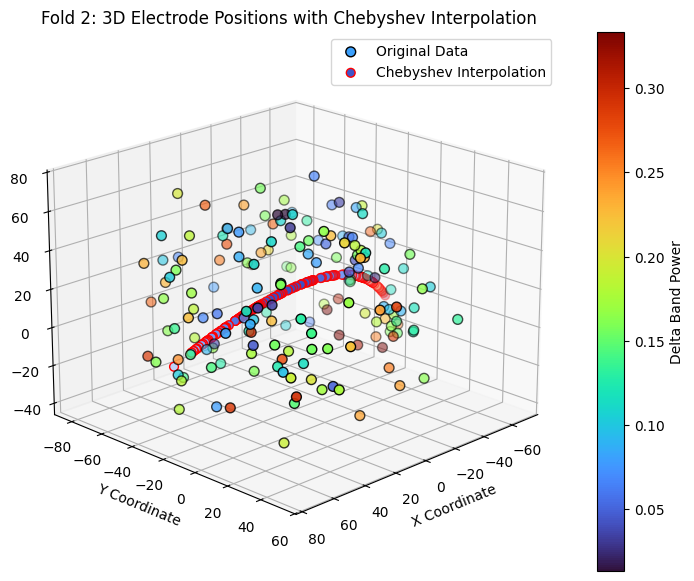


=== Fold 3 ===
MSE  : 0.0053
MAE  : 0.0606
RMSE : 0.0729
R²   : -0.0009


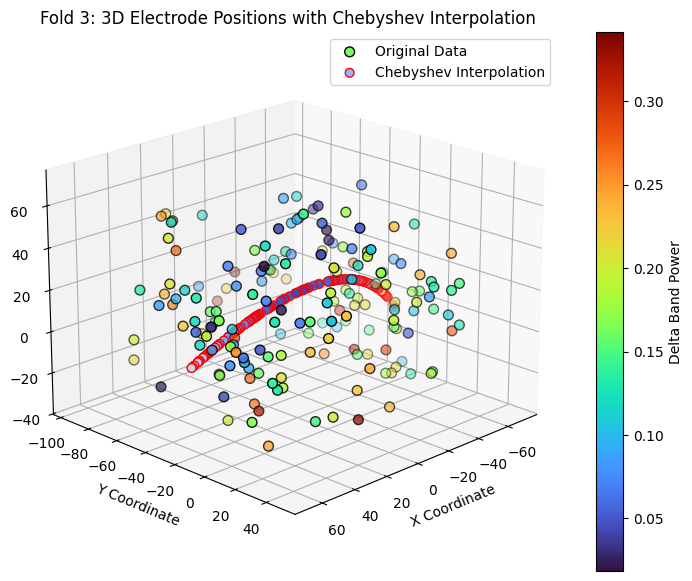


=== Fold 4 ===
MSE  : 0.0042
MAE  : 0.0530
RMSE : 0.0647
R²   : 0.0050


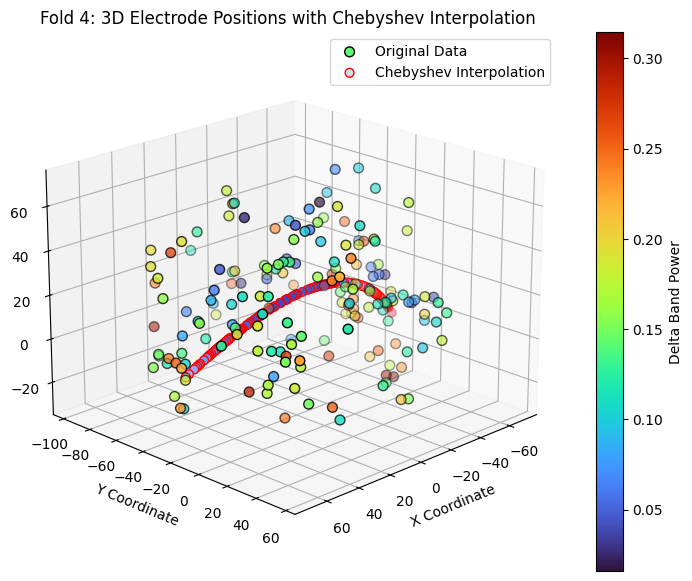


=== Fold 5 ===
MSE  : 0.0048
MAE  : 0.0559
RMSE : 0.0691
R²   : -0.0095


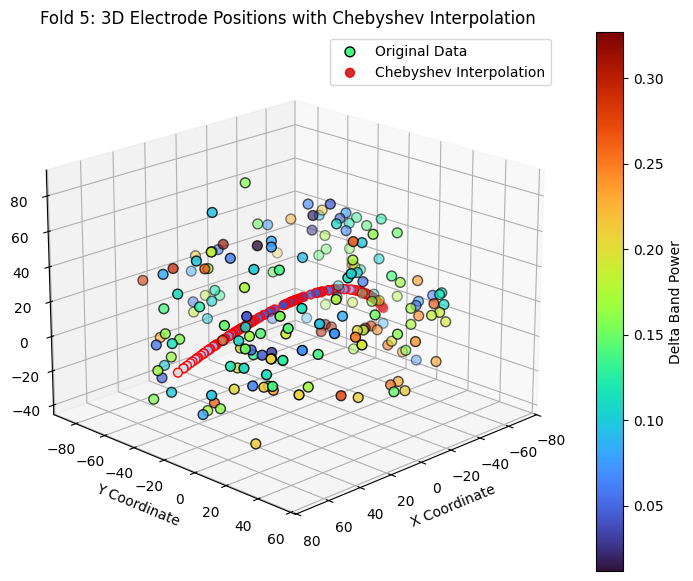


=== Fold 6 ===
MSE  : 0.0049
MAE  : 0.0581
RMSE : 0.0698
R²   : 0.0012


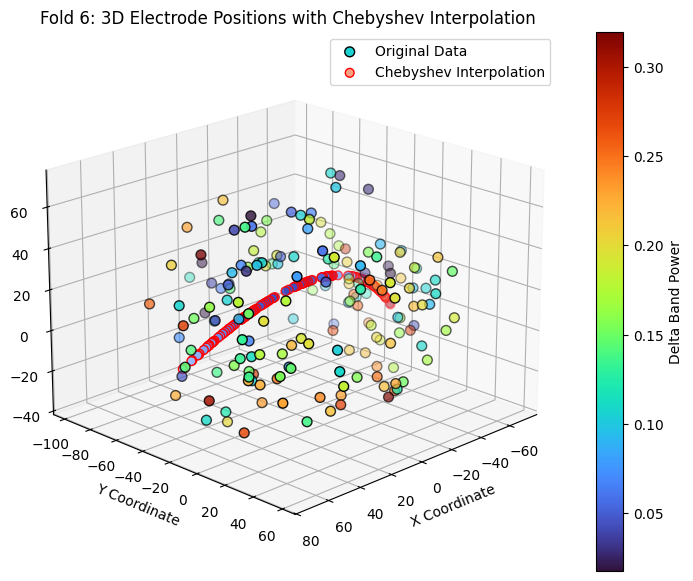


=== Fold 7 ===
MSE  : 0.0051
MAE  : 0.0590
RMSE : 0.0716
R²   : -0.0103


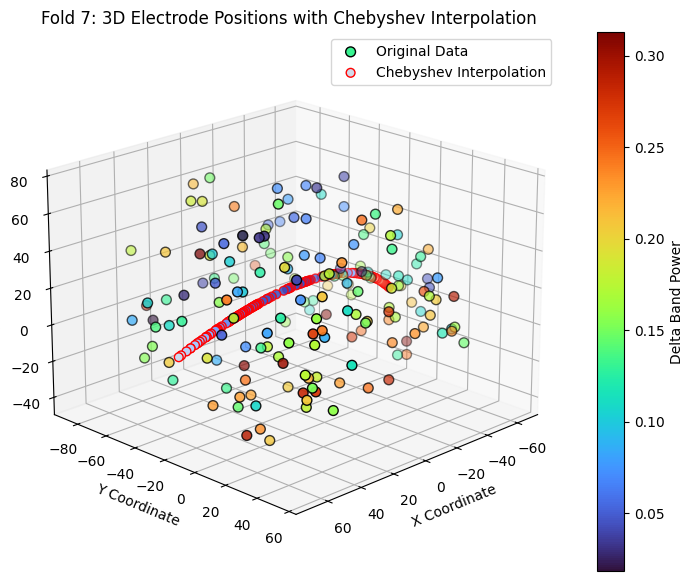


=== Fold 8 ===
MSE  : 0.0051
MAE  : 0.0583
RMSE : 0.0711
R²   : 0.0123


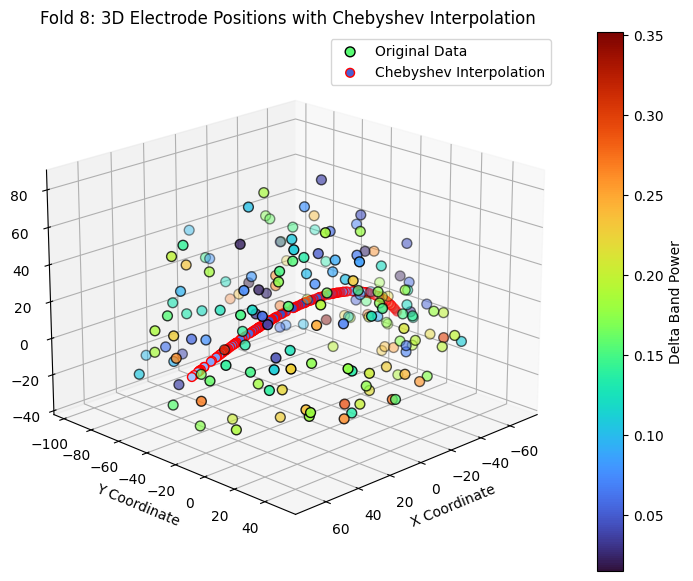


=== Fold 9 ===
MSE  : 0.0040
MAE  : 0.0526
RMSE : 0.0633
R²   : -0.0153


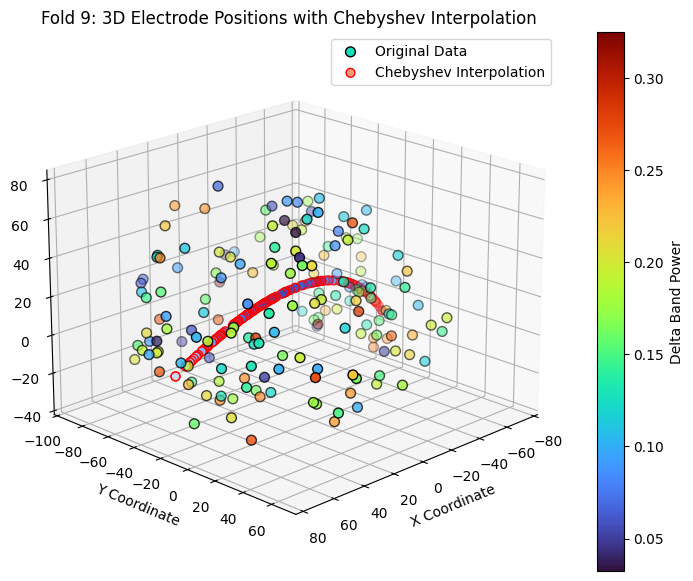


=== Fold 10 ===
MSE  : 0.0046
MAE  : 0.0568
RMSE : 0.0682
R²   : 0.0071


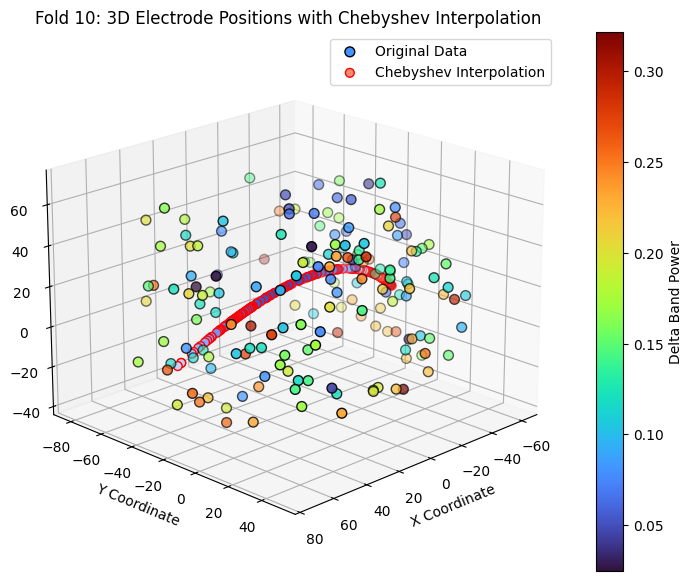


=== Final Evaluation Across 10 Folds ===
Mean MSE  : 0.0048 ± 0.0004
Mean MAE  : 0.0570 ± 0.0025
Mean RMSE : 0.0692 ± 0.0031
Mean R²   : 0.0007 ± 0.0096

T-test between MSE and MAE across folds:
T-statistic: -75.0790, P-value: 0.0000
Significant difference found (p < 0.05), suggesting MSE and MAE distributions are different.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from numpy.polynomial.chebyshev import Chebyshev
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from scipy.stats import ttest_rel  # T-test for paired samples

# Load dataset
samples = np.load('coords.npy')  # 3D electrode coordinates
band_powers = np.load('band_powers.npy', allow_pickle=True).item()  # Frequency band power data

# Convert to NumPy arrays to avoid indexing issues
X = np.array(samples[:, 0])
Y = np.array(samples[:, 1])
Z = np.array(samples[:, 2])
delta_powers = np.array(band_powers['Delta'])  # Ensure it's a NumPy array

# Define KFold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Function to compute evaluation metrics
def compute_metrics(true_values, predicted_values):
    """Compute evaluation metrics: MSE, MAE, RMSE, R²."""
    mse = mean_squared_error(true_values, predicted_values)
    mae = mean_absolute_error(true_values, predicted_values)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values, predicted_values)
    return mse, mae, rmse, r2

# Store evaluation metrics
mse_scores = []
mae_scores = []
rmse_scores = []
r2_scores = []

# Perform 10-fold cross-validation
fold = 1
for train_index, test_index in kf.split(X):
    print(f"\n=== Fold {fold} ===")

    # Split data into training and testing sets
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = Y[train_index], Y[test_index]
    Z_train, Z_test = Z[train_index], Z[test_index]
    Delta_train, Delta_test = delta_powers[train_index], delta_powers[test_index]

    # Sort X_train to ensure monotonicity for Chebyshev fitting
    sort_idx = np.argsort(X_train)
    X_train = X_train[sort_idx]
    Y_train = Y_train[sort_idx]
    Z_train = Z_train[sort_idx]
    Delta_train = Delta_train[sort_idx]

    # Fit Chebyshev polynomials for Y, Z, and Delta band power
    chebyshev_y = Chebyshev.fit(X_train, Y_train, deg=2)
    chebyshev_z = Chebyshev.fit(X_train, Z_train, deg=2)
    chebyshev_delta = Chebyshev.fit(X_train, Delta_train, deg=2)

    # Interpolate values for test X positions
    Y_interp = chebyshev_y(X_test)
    Z_interp = chebyshev_z(X_test)
    Delta_interp = chebyshev_delta(X_test)

    # Compute metrics for this fold
    mse, mae, rmse, r2 = compute_metrics(Delta_test, Delta_interp)

    # Store scores
    mse_scores.append(mse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    # Print evaluation metrics
    print(f"MSE  : {mse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    # Plot 3D interpolation result
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Original test data points
    sc = ax.scatter(X_test, Y_test, Z_test, c=Delta_test, cmap='turbo', label="Original Data", s=50, edgecolor='k')

    # Interpolated test data points
    sc_interp = ax.scatter(X_test, Y_interp, Z_interp, c=Delta_interp, cmap='coolwarm', label="Chebyshev Interpolation", s=40, edgecolor='r')

    # Color bar
    cbar = plt.colorbar(sc)
    cbar.set_label('Delta Band Power')

    # Axis labels
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_zlabel('Z Coordinate')
    ax.set_title(f'Fold {fold}: 3D Electrode Positions with Chebyshev Interpolation')

    # Show legend
    ax.legend()

    # Adjust view angle
    ax.view_init(elev=20, azim=45)

    # Show the plot
    plt.show()

    fold += 1

# Perform t-test to compare MSE and MAE scores across folds
t_stat, p_value = ttest_rel(mse_scores, mae_scores)  # Using paired t-test

# Print final evaluation
print("\n=== Final Evaluation Across 10 Folds ===")
print(f"Mean MSE  : {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")
print(f"Mean MAE  : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"Mean RMSE : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"Mean R²   : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")

# Print t-test results
print(f"\nT-test between MSE and MAE across folds:")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

# Interpretation of t-test
if p_value < 0.05:
    print("Significant difference found (p < 0.05), suggesting MSE and MAE distributions are different.")
else:
    print("No significant difference found (p >= 0.05), suggesting MSE and MAE distributions are similar.")


new dataset: expresson.npy express_coords.npy

📌 Data Types
expression type: <class 'numpy.ndarray'>
expression_coords type: <class 'numpy.ndarray'>

📌 Data Dimensions and Size
expression shape: ()
expression total elements: 1
expression_coords shape: (1759, 3)
expression_coords total elements: 5277

📌 expression is a scalar: {'GRIA1': [-0.5243785430453755, 0.4298391443874868, 1.0152033998869667, 0.6693615715102614, -1.0763314293440622, 0.2732613151710544, -0.20172848755926945, 0.37363876556704856, 1.974953514967616, 0.9460453348904562, 1.5881408937119856, -1.4185443337005987, -1.7158320289556481, 1.475939768942641, -0.16600052940873297, -0.6254428566664779, 1.1624669477523748, -0.04439850444225276, 0.722536125126657, -0.4698152153547003, -0.5490666318342249, -0.3191412518972643, -0.7320195129379019, 0.08338990477712964, 0.4950969728189794, 0.1618817383661105, -0.5691035459682456, 0.6131125464846122, -1.5836771237696798, -0.2914087557887372, -0.49848079620160957, -0.8372134373026328, -0.26177755575184086, 0.42637490813750467, -0.93

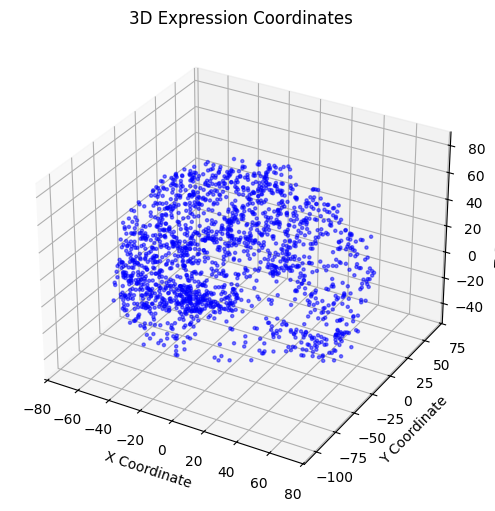

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1️⃣ Load dataset
expression = np.load("expression.npy", allow_pickle=True)  # Can be an array or a dictionary
expression_coords = np.load("expression_coords.npy")  # 3D coordinate data

# 2️⃣ Check data types
print("📌 Data Types")
print(f"expression type: {type(expression)}")
print(f"expression_coords type: {type(expression_coords)}")

# 3️⃣ Check data dimensions
if isinstance(expression, np.ndarray):
    print("\n📌 Data Dimensions and Size")
    print(f"expression shape: {expression.shape}")
    print(f"expression total elements: {expression.size}")

if isinstance(expression_coords, np.ndarray):
    print(f"expression_coords shape: {expression_coords.shape}")
    print(f"expression_coords total elements: {expression_coords.size}")

# 4️⃣ Preview first few rows of data
# Reload expression.npy to ensure proper loading
expression = np.load("expression.npy", allow_pickle=True)

# Check if expression is a scalar (zero-dimensional array)
if expression.shape == ():
    print("\n📌 expression is a scalar:", expression)
else:
    print("\n📌 expression shape:", expression.shape)
    print("First 5 rows of expression:\n", expression[:5])

# 5️⃣ Compute statistical information (if numeric data)
if isinstance(expression, np.ndarray) and np.issubdtype(expression.dtype, np.number):
    print("\n📌 Statistical Information (expression)")
    print(f"Mean: {np.mean(expression):.4f}, Std Dev: {np.std(expression):.4f}")
    print(f"Min: {np.min(expression):.4f}, Max: {np.max(expression):.4f}")

if isinstance(expression_coords, np.ndarray) and np.issubdtype(expression_coords.dtype, np.number):
    print("\n📌 Statistical Information (expression_coords)")
    print(f"Mean: {np.mean(expression_coords, axis=0)}")
    print(f"Min: {np.min(expression_coords, axis=0)}")
    print(f"Max: {np.max(expression_coords, axis=0)}")

# 6️⃣ Histogram visualization of expression data distribution
if isinstance(expression, np.ndarray) and np.issubdtype(expression.dtype, np.number):
    plt.figure(figsize=(7, 5))
    plt.hist(expression.flatten(), bins=50, alpha=0.7, color='blue')
    plt.xlabel("Expression Value")
    plt.ylabel("Frequency")
    plt.title("Expression Data Distribution")
    plt.show()

# 7️⃣ 3D visualization of expression_coords data
if isinstance(expression_coords, np.ndarray) and expression_coords.shape[1] == 3:
    X, Y, Z = expression_coords[:, 0], expression_coords[:, 1], expression_coords[:, 2]
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X, Y, Z, s=5, c='b', alpha=0.5)
    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")
    ax.set_zlabel("Z Coordinate")
    ax.set_title("3D Expression Coordinates")
    plt.show()



=== Fold 1 ===
MSE  : 0.8370
MAE  : 0.7100
RMSE : 0.9149
R²   : -0.0172


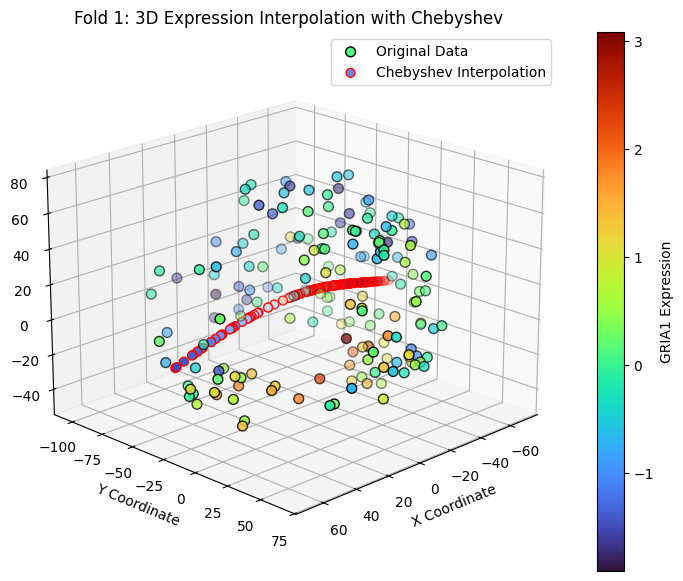


=== Fold 2 ===
MSE  : 1.1364
MAE  : 0.8260
RMSE : 1.0660
R²   : -0.0097


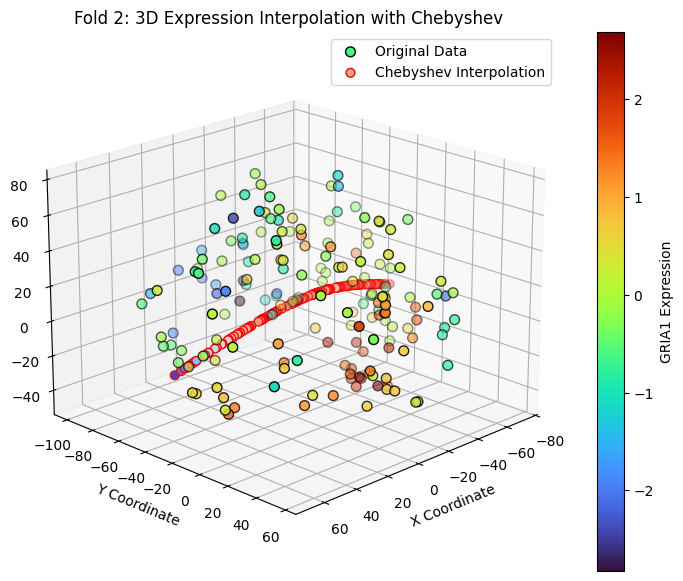


=== Fold 3 ===
MSE  : 1.1746
MAE  : 0.8457
RMSE : 1.0838
R²   : -0.0047


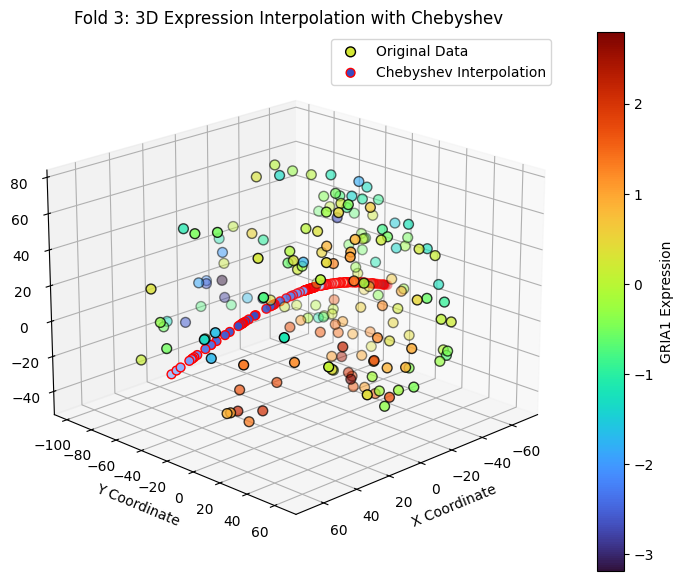


=== Fold 4 ===
MSE  : 0.9466
MAE  : 0.7879
RMSE : 0.9729
R²   : -0.0224


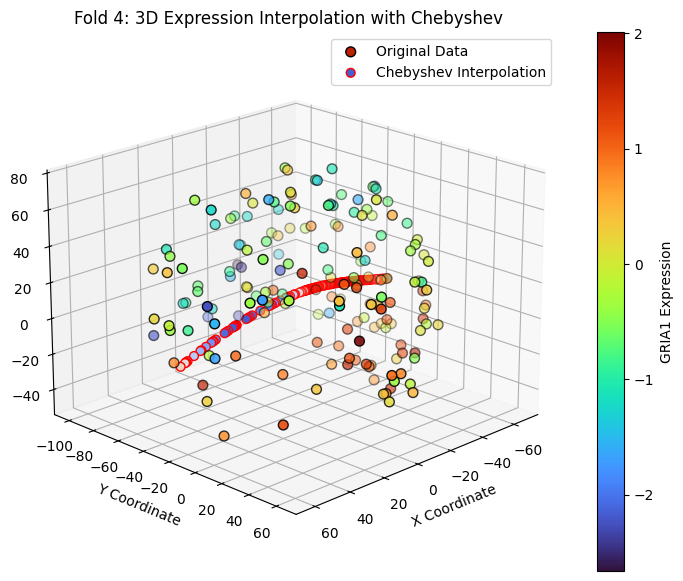


=== Fold 5 ===
MSE  : 1.0067
MAE  : 0.7492
RMSE : 1.0033
R²   : -0.0057


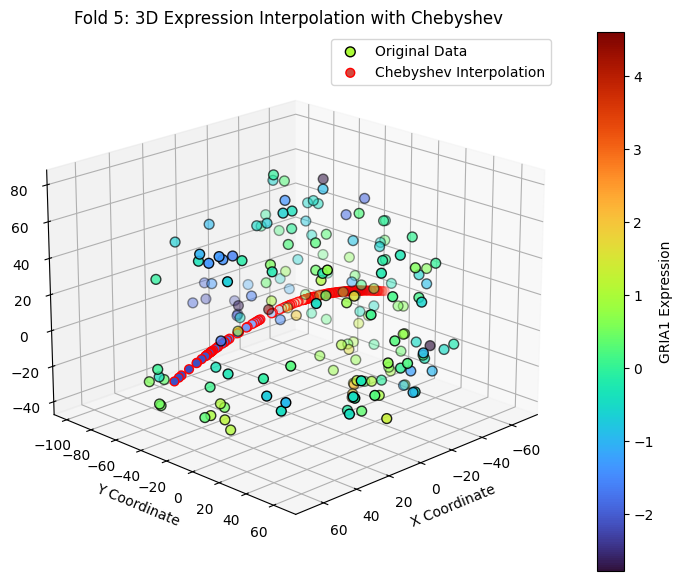


=== Fold 6 ===
MSE  : 0.8835
MAE  : 0.7549
RMSE : 0.9400
R²   : -0.0100


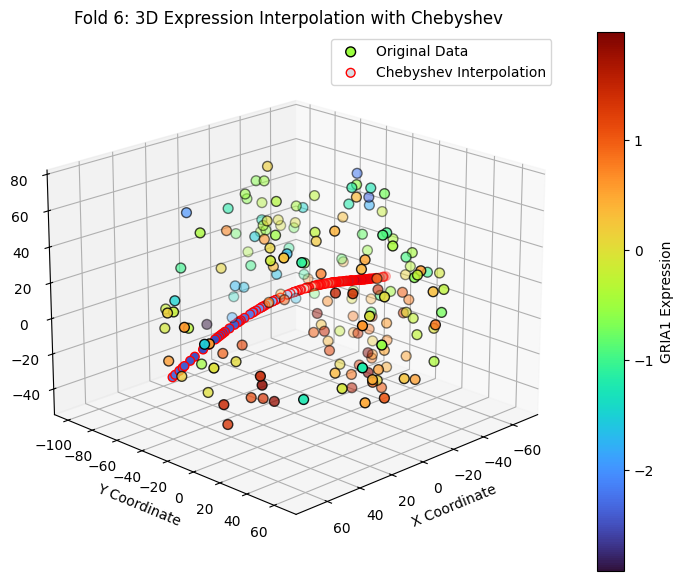


=== Fold 7 ===
MSE  : 0.9805
MAE  : 0.7991
RMSE : 0.9902
R²   : -0.0168


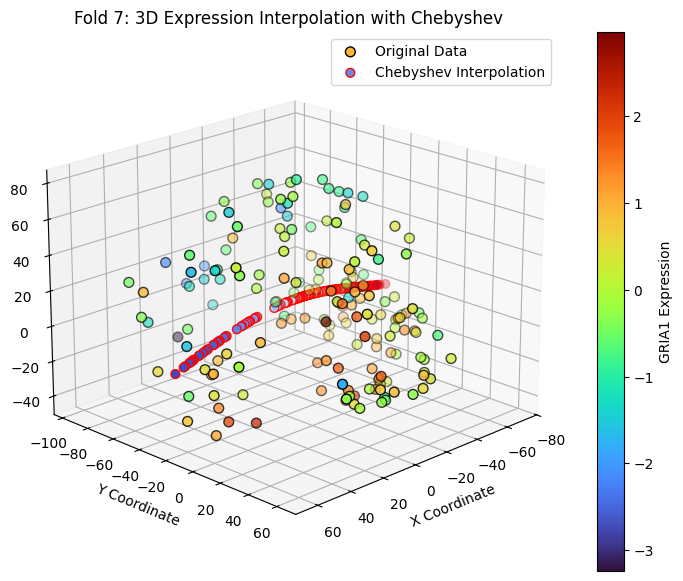


=== Fold 8 ===
MSE  : 0.8816
MAE  : 0.7613
RMSE : 0.9390
R²   : -0.0195


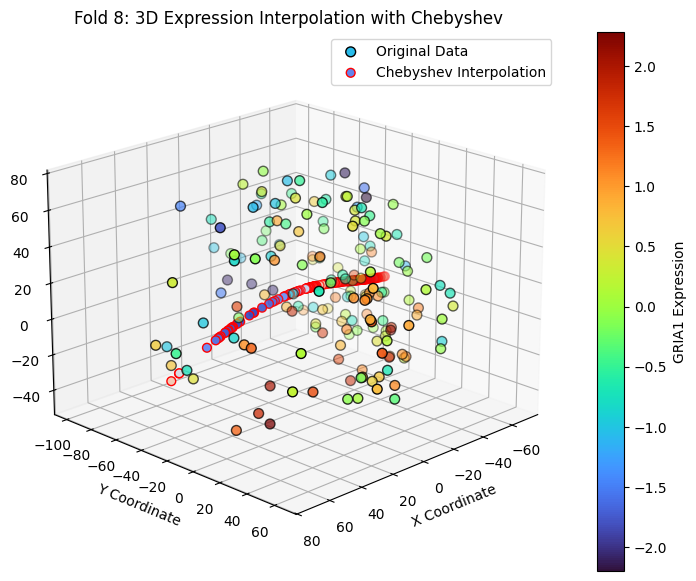


=== Fold 9 ===
MSE  : 1.1163
MAE  : 0.8274
RMSE : 1.0565
R²   : -0.0023


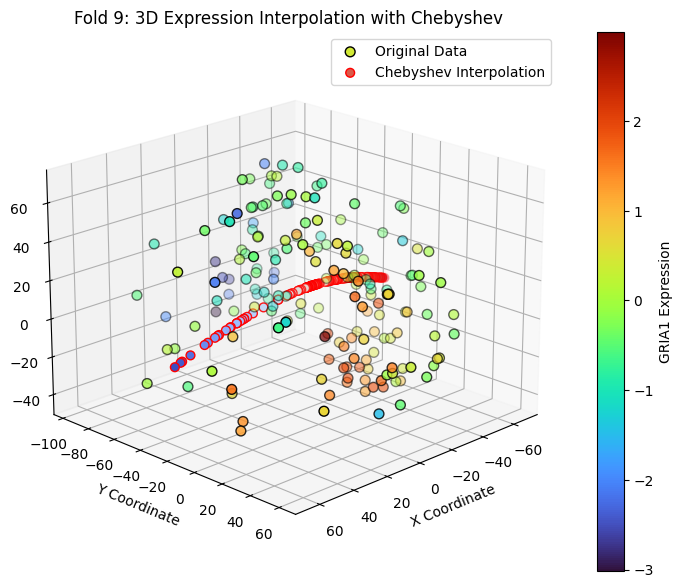


=== Fold 10 ===
MSE  : 1.0617
MAE  : 0.8129
RMSE : 1.0304
R²   : 0.0006


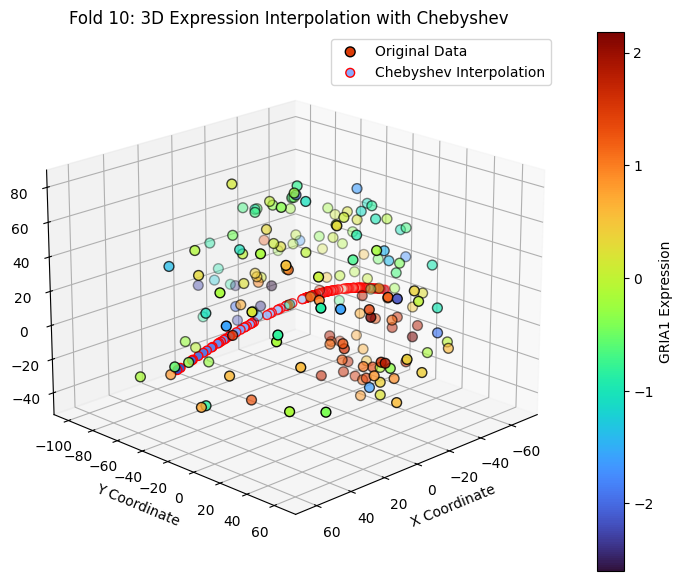


=== Final Evaluation Across 10 Folds ===
Mean MSE  : 1.0025 ± 0.1113
Mean MAE  : 0.7874 ± 0.0406
Mean RMSE : 0.9997 ± 0.0556
Mean R²   : -0.0108 ± 0.0075

T-test between MSE and MAE across folds:
T-statistic: 8.4030, P-value: 0.0000
Significant difference found (p < 0.05), suggesting MSE and MAE distributions are different.


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from numpy.polynomial.chebyshev import Chebyshev
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from scipy.stats import ttest_rel  # T-test for paired samples

# ✅ 1️⃣ Load dataset
samples = np.load('expression_coords.npy')  # 3D spatial coordinates
expression_data = np.load('expression.npy', allow_pickle=True).item()  # Gene expression data (dictionary)

# ✅ 2️⃣ Select a gene for interpolation
gene_name = 'GRIA1'  # You can change this to another gene name
if gene_name not in expression_data:
    raise ValueError(f"Gene '{gene_name}' not found in expression.npy! Available genes: {list(expression_data.keys())}")

# ✅ 3️⃣ Convert data into NumPy arrays
X = np.array(samples[:, 0])  # X coordinates
Y = np.array(samples[:, 1])  # Y coordinates
Z = np.array(samples[:, 2])  # Z coordinates
gene_expression = np.array(expression_data[gene_name])  # Expression values for the selected gene

# ✅ 4️⃣ Define KFold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# ✅ 5️⃣ Function to compute evaluation metrics
def compute_metrics(true_values, predicted_values):
    """Compute MSE, MAE, RMSE, and R² metrics."""
    mse = mean_squared_error(true_values, predicted_values)
    mae = mean_absolute_error(true_values, predicted_values)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values, predicted_values)
    return mse, mae, rmse, r2

# ✅ 6️⃣ Store evaluation metrics
mse_scores = []
mae_scores = []
rmse_scores = []
r2_scores = []

# ✅ 7️⃣ Perform 10-fold cross-validation
fold = 1
for train_index, test_index in kf.split(X):
    print(f"\n=== Fold {fold} ===")

    # Split dataset into training and testing sets
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = Y[train_index], Y[test_index]
    Z_train, Z_test = Z[train_index], Z[test_index]
    Expression_train, Expression_test = gene_expression[train_index], gene_expression[test_index]

    # Ensure X_train is in ascending order (required for Chebyshev interpolation)
    sort_idx = np.argsort(X_train)
    X_train = X_train[sort_idx]
    Y_train = Y_train[sort_idx]
    Z_train = Z_train[sort_idx]
    Expression_train = Expression_train[sort_idx]

    # Fit Chebyshev polynomials for Y, Z, and gene expression
    chebyshev_y = Chebyshev.fit(X_train, Y_train, deg=3)  # Adjust degree for optimal fitting
    chebyshev_z = Chebyshev.fit(X_train, Z_train, deg=3)
    chebyshev_expression = Chebyshev.fit(X_train, Expression_train, deg=3)

    # Perform interpolation
    Y_interp = chebyshev_y(X_test)
    Z_interp = chebyshev_z(X_test)
    Expression_interp = chebyshev_expression(X_test)

    # Compute evaluation metrics
    mse, mae, rmse, r2 = compute_metrics(Expression_test, Expression_interp)

    # Store evaluation results
    mse_scores.append(mse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    # Print metrics for this fold
    print(f"MSE  : {mse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    # 📌 8️⃣ Plot 3D interpolation results
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Original test data points
    sc = ax.scatter(X_test, Y_test, Z_test, c=Expression_test, cmap='turbo', label="Original Data", s=50, edgecolor='k')

    # Interpolated test data points
    sc_interp = ax.scatter(X_test, Y_interp, Z_interp, c=Expression_interp, cmap='coolwarm', label="Chebyshev Interpolation", s=40, edgecolor='r')

    # Color bar
    cbar = plt.colorbar(sc)
    cbar.set_label(f'{gene_name} Expression')

    # Axis labels
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_zlabel('Z Coordinate')
    ax.set_title(f'Fold {fold}: 3D Expression Interpolation with Chebyshev')

    # Show legend
    ax.legend()

    # Adjust view angle
    ax.view_init(elev=20, azim=45)

    # Display the plot
    plt.show()

    fold += 1

# ✅ 9️⃣ Perform t-test to compare MSE and MAE
t_stat, p_value = ttest_rel(mse_scores, mae_scores)  # Paired t-test

# ✅ 🔟 Print final evaluation results
print("\n=== Final Evaluation Across 10 Folds ===")
print(f"Mean MSE  : {np.mean(mse_scores):.4f} ± {np.std(mse_scores):.4f}")
print(f"Mean MAE  : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"Mean RMSE : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"Mean R²   : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")

# ✅ Print t-test results
print(f"\nT-test between MSE and MAE across folds:")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

# ✅ Interpret t-test results
if p_value < 0.05:
    print("Significant difference found (p < 0.05), suggesting MSE and MAE distributions are different.")
else:
    print("No significant difference found (p >= 0.05), suggesting MSE and MAE distributions are similar.")
